# México y los ODS — Lo que los números nos dicen (Interactivo)
### Narrativa visual con Plotly · HackODS 2026

> **Faltan 4 años para 2030.** En 2015, México se comprometió con los 17 Objetivos de Desarrollo Sostenible.  
> Los datos del INEGI sobre 333 indicadores ODS revelan dónde estamos realmente.  
> Esta narrativa muestra los 5 problemas de mayor prioridad — con gráficas interactivas.

In [1]:

# ── Helper: convertir hex a rgba ─────────────────────────────────────────────
def hex_to_rgba(hex_color, alpha=0.15):
    h = hex_color.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'

import pandas as pd
import numpy as np
import networkx as nx
import ast
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── Paleta de colores oficial ODS ──────────────────────────────────────────────
ODS_COLORS = {
    1:  '#E5243B', 2:  '#DDA63A', 3:  '#4C9F38', 4:  '#C5192D',
    5:  '#FF3A21', 6:  '#26BDE2', 7:  '#FCC30B', 8:  '#A21942',
    9:  '#FD6925', 10: '#DD1367', 11: '#FD9D24', 12: '#BF8B2E',
    13: '#3F7E44', 14: '#0A97D9', 15: '#56C02B', 16: '#00689D',
    17: '#19486A'
}
ODS_NAMES = {
    1:'Fin de la Pobreza', 2:'Hambre Cero', 3:'Salud y Bienestar',
    4:'Educación de Calidad', 5:'Igualdad de Género', 6:'Agua Limpia',
    7:'Energía Asequible', 8:'Trabajo Decente', 9:'Industria e Innovación',
    10:'Reducción de Desigualdades', 11:'Ciudades Sostenibles',
    12:'Producción Responsable', 13:'Acción por el Clima',
    14:'Vida Submarina', 15:'Vida de Ecosistemas', 16:'Paz y Justicia',
    17:'Alianzas'
}

# ── Tema oscuro global para Plotly ────────────────────────────────────────────
DARK_LAYOUT = dict(
    paper_bgcolor='#0D1117',
    plot_bgcolor='#161B22',
    font_color='#E6EDF3',
    font_family='Arial',
)

# ── Carga de datos ─────────────────────────────────────────────────────────────
largo      = pd.read_csv('../data/consolidated/indicadores_largo.csv')
meta       = pd.read_csv('../data/consolidated/metadatos_indicadores.csv')
corr_altas = pd.read_csv('../data/consolidated/correlaciones_altas.csv')
pares_ods  = pd.read_csv('../data/consolidated/pares_ods_correlaciones.csv')

print(f'Indicadores con datos: {meta[meta.loaded].shape[0]} / {meta.shape[0]}')
print(f'Observaciones totales: {largo.shape[0]:,}')
print(f'Pares con correlación alta (|r|≥0.7): {corr_altas.shape[0]:,}')
print(f'Años cubiertos: {int(largo.periodo.min())} – {int(largo.periodo.max())}')

Indicadores con datos: 292 / 333
Observaciones totales: 3,611
Pares con correlación alta (|r|≥0.7): 3,758
Años cubiertos: 1970 – 2026


---
## ACTO 1 · El sistema interconectado
### ¿Cómo se relacionan los 17 ODS entre sí en México?

Cada nodo es un ODS. El grosor de cada arista representa cuántos indicadores tienen correlación alta (|r| ≥ 0.7) entre esos dos ODS.  
**Los ODS más conectados son los que más arrastran al resto cuando fallan.**  
> Pasa el cursor sobre los nodos para ver el nombre del ODS y su centralidad.

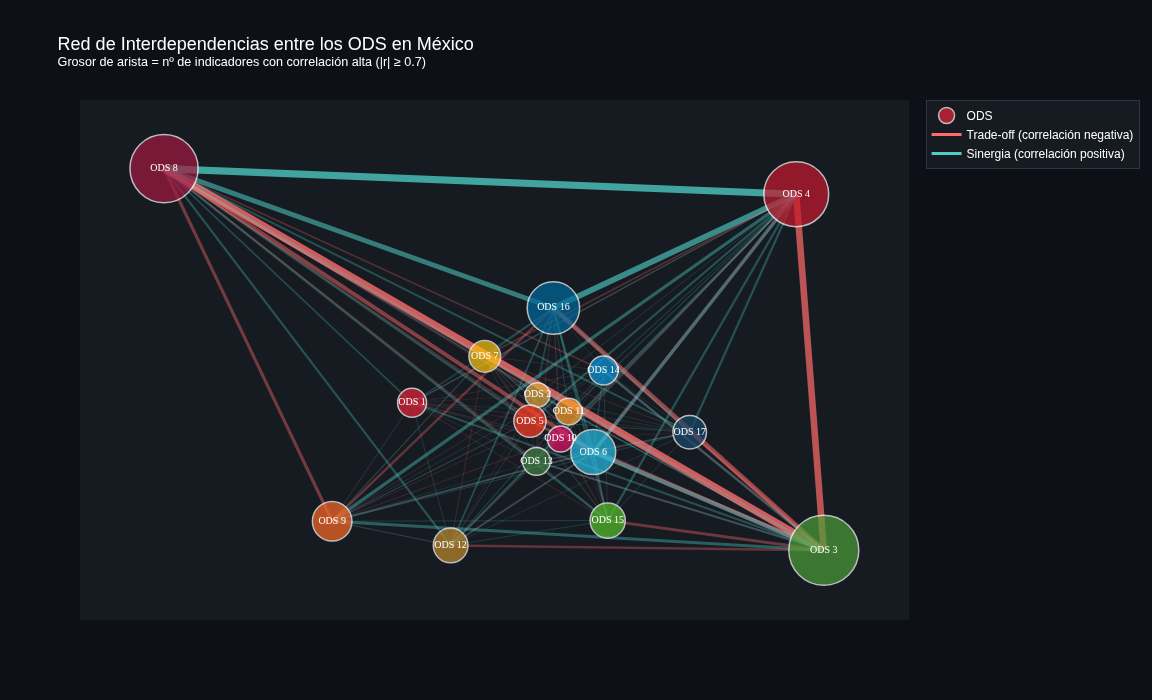

In [2]:
# ── Construir grafo ────────────────────────────────────────────────────────────
G = nx.Graph()
for i in range(1, 18):
    G.add_node(i)

for _, row in pares_ods.iterrows():
    pair = ast.literal_eval(row['ods_pair'])
    a, b = pair
    if a != b:
        G.add_edge(a, b, weight=row['n_correlaciones'], avg_corr=row['corr_promedio'])

weighted_degree = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}
pos = nx.kamada_kawai_layout(G, weight='weight')

# ── Construir trazas de aristas ────────────────────────────────────────────────
max_w = max(d['weight'] for _, _, d in G.edges(data=True))

edge_traces = []
for u, v, d in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    w = d['weight']
    avg = d['avg_corr']
    color = '#FF6B6B' if avg < -0.05 else '#4ECDC4' if avg > 0.05 else '#A8DADC'
    width = 0.5 + 7 * (w / max_w)
    alpha = 0.15 + 0.65 * (w / max_w)

    edge_traces.append(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode='lines',
        line=dict(width=width, color=color),
        opacity=alpha,
        hoverinfo='none',
        showlegend=False,
    ))

# ── Traza de nodos ─────────────────────────────────────────────────────────────
max_wd = max(weighted_degree.values())
node_x = [pos[n][0] for n in G.nodes()]
node_y = [pos[n][1] for n in G.nodes()]
node_sizes  = [20 + 50 * (weighted_degree[n] / max_wd) for n in G.nodes()]
node_colors = [ODS_COLORS[n] for n in G.nodes()]
node_text   = [f'ODS {n}' for n in G.nodes()]
node_hover  = [
    f'<b>ODS {n}: {ODS_NAMES[n]}</b><br>'
    f'Peso conectividad: {weighted_degree[n]}<br>'
    f'Vecinos directos: {G.degree(n)}'
    for n in G.nodes()
]

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    marker=dict(size=node_sizes, color=node_colors,
                line=dict(width=1.5, color='white')),
    text=node_text,
    textposition='middle center',
    textfont=dict(size=10, color='white', family='Arial Black'),
    hovertext=node_hover,
    hoverinfo='text',
    name='ODS',
)

# ── Leyenda manual ────────────────────────────────────────────────────────────
legend_traces = [
    go.Scatter(x=[None], y=[None], mode='lines',
               line=dict(color='#FF6B6B', width=3),
               name='Trade-off (correlación negativa)'),
    go.Scatter(x=[None], y=[None], mode='lines',
               line=dict(color='#4ECDC4', width=3),
               name='Sinergia (correlación positiva)'),
]

fig = go.Figure(
    data=edge_traces + [node_trace] + legend_traces,
    layout=go.Layout(
        title=dict(
            text='Red de Interdependencias entre los ODS en México<br>'
                 '<sup>Grosor de arista = nº de indicadores con correlación alta (|r| ≥ 0.7)</sup>',
            font=dict(size=18, color='white'),
        ),
        **DARK_LAYOUT,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        hovermode='closest',
        legend=dict(
            bgcolor='#161B22', bordercolor='#30363D', borderwidth=1,
            font=dict(color='white'),
        ),
        height=700,
    )
)
fig.show()

---
## ACTO 2 · Alarma roja: El colapso de la salud pública
### ODS 3 — El objetivo más interconectado está fallando

La cobertura de vacunación cayó **20 puntos porcentuales** en una década.  
Las enfermedades vectoriales (dengue, malaria, zika) crecen año con año.  
> Activa/desactiva series con el clic en la leyenda. Pasa el cursor para ver valores exactos.

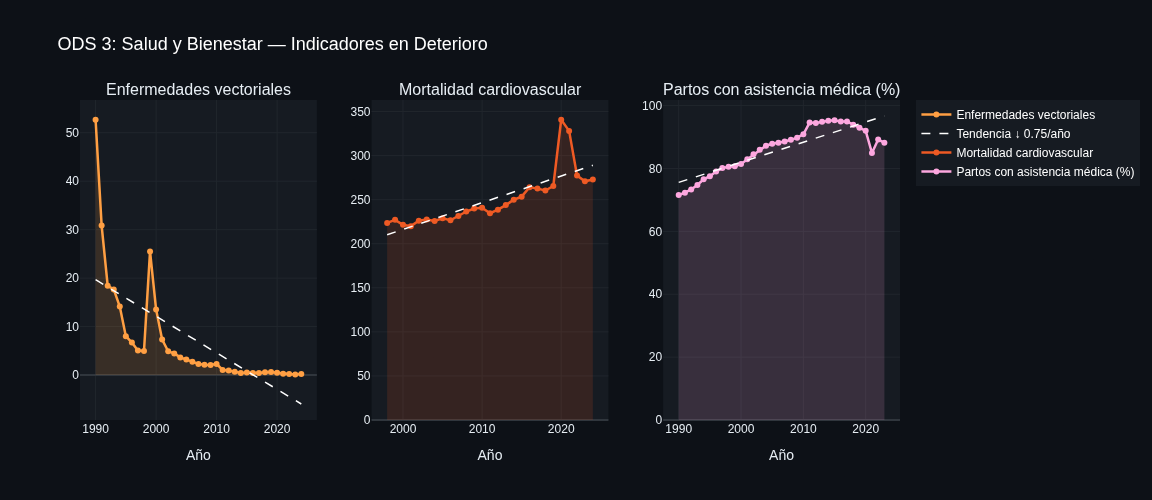

In [3]:
# ── Indicadores ODS 3 ──────────────────────────────────────────────────────────
ods3 = largo[largo.ods_number == 3].copy()
ods3_counts = ods3.groupby('indicator_id').size().reset_index(name='n')
ids_validos = ods3_counts[ods3_counts.n >= 5]['indicator_id'].tolist()

FOCUS = {
    '3.b.1': ('Cobertura vacunación (%)',   '#FF6B6B'),
    '3.3.3': ('Enfermedades vectoriales',    '#FF9F43'),
    '3.4.1': ('Mortalidad cardiovascular',   '#EE5A24'),
    '3.1.2': ('Partos con asistencia médica (%)', '#FDA7DF'),
}

focus_disp = {k: v for k, v in FOCUS.items()
              if any(k.lower() == x.lower() for x in ids_validos)}

if len(focus_disp) < 2:
    top4 = ods3_counts.sort_values('n', ascending=False).head(4)['indicator_id'].tolist()
    cols = ['#FF6B6B', '#FF9F43', '#EE5A24', '#FDA7DF']
    focus_disp = {
        iid: (ods3[ods3.indicator_id == iid]['title'].iloc[0][:50], c)
        for iid, c in zip(top4, cols)
    }

# ── Figura con subplots (un panel por indicador) ──────────────────────────────
n_ind = len(focus_disp)
fig = make_subplots(
    rows=1, cols=n_ind,
    subplot_titles=[v[0] for v in focus_disp.values()],
    shared_yaxes=False,
)

for col_i, (ind_id, (label, color)) in enumerate(focus_disp.items(), start=1):
    serie = ods3[ods3.indicator_id == ind_id].sort_values('periodo')
    x = serie['periodo'].values
    y = serie['valor'].values
    unit = serie['unit'].iloc[0] if 'unit' in serie.columns else ''

    # Área de relleno
    fig.add_trace(go.Scatter(
        x=x, y=y, fill='tozeroy',
        fillcolor=hex_to_rgba(color, 0.15),
        line=dict(color=color, width=0),
        hoverinfo='none', showlegend=False,
    ), row=1, col=col_i)

    # Serie principal
    hover_tmpl = f'<b>{label}</b><br>Año: %{{x}}<br>Valor: %{{y:.2f}} {unit}<extra></extra>'
    fig.add_trace(go.Scatter(
        x=x, y=y,
        mode='lines+markers',
        line=dict(color=color, width=2.5),
        marker=dict(size=6, color=color),
        name=label,
        hovertemplate=hover_tmpl,
    ), row=1, col=col_i)

    # Línea de tendencia
    if len(x) >= 3:
        z = np.polyfit(x, y, 1)
        y_trend = np.poly1d(z)(x)
        dir_label = f'↑ {abs(z[0]):.2f}/año' if z[0] > 0 else f'↓ {abs(z[0]):.2f}/año'
        fig.add_trace(go.Scatter(
            x=x, y=y_trend,
            mode='lines',
            line=dict(color='white', width=1.5, dash='dash'),
            name=f'Tendencia {dir_label}',
            hoverinfo='skip',
            showlegend=(col_i == 1),
        ), row=1, col=col_i)

fig.update_layout(
    title=dict(
        text='ODS 3: Salud y Bienestar — Indicadores en Deterioro',
        font=dict(size=18, color='white'),
    ),
    **DARK_LAYOUT,
    height=500,
    legend=dict(bgcolor='#161B22', bordercolor='#30363D',
                font=dict(color='white')),
    hovermode='x unified',
)
fig.update_xaxes(title_text='Año', gridcolor='#21262D', zerolinecolor='#30363D')
fig.update_yaxes(gridcolor='#21262D', zerolinecolor='#30363D')
fig.show()

---
## ACTO 3 · El trilema: Trabajo ↔ Agua ↔ Salud
### Cuando el crecimiento económico daña el bienestar

El análisis de correlaciones revela una tensión estructural:  
conforme mejoran los indicadores de **empleo (ODS 8)**, los de **agua limpia (ODS 6)** y **salud (ODS 3)** tienden a empeorar.  
> Pasa el cursor sobre cada celda del heatmap para ver la correlación exacta. Haz clic en las barras para detalles.

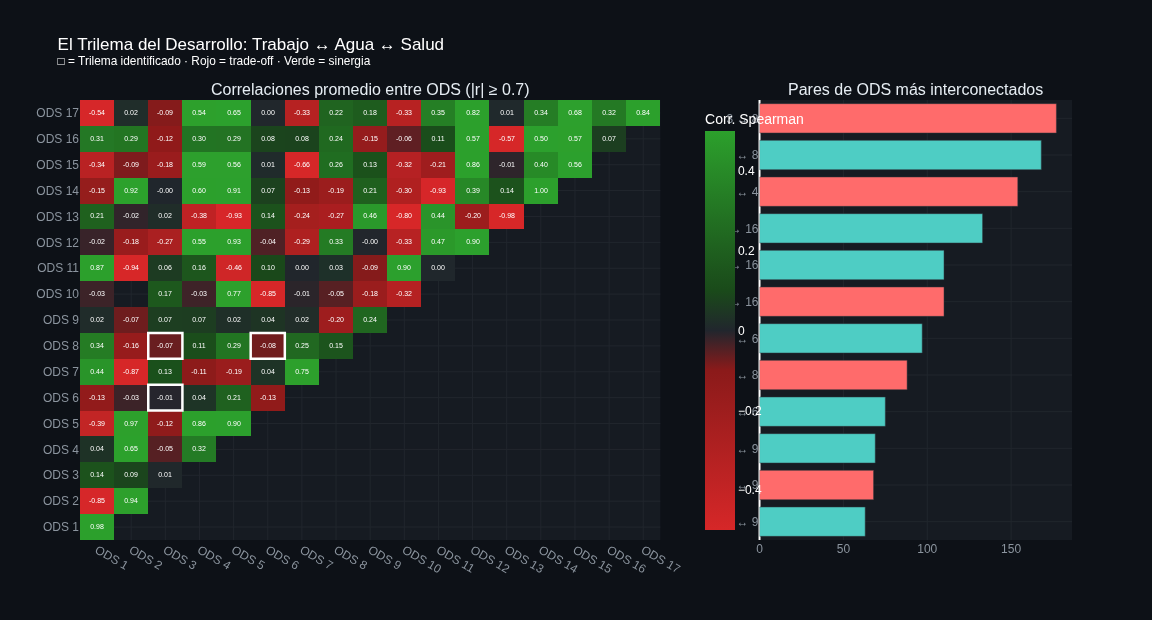

In [4]:
# ── Construir matriz ODS × ODS ─────────────────────────────────────────────────
matrix = pd.DataFrame(np.nan, index=range(1, 18), columns=range(1, 18))
arr = matrix.to_numpy(copy=True)
np.fill_diagonal(arr, 0)
matrix = pd.DataFrame(arr, index=range(1, 18), columns=range(1, 18))

for _, row in pares_ods.iterrows():
    try:
        pair = ast.literal_eval(row['ods_pair'])
    except Exception:
        continue
    a, b = pair
    val = row['corr_promedio']
    matrix.loc[a, b] = val
    matrix.loc[b, a] = val

labels_ods = [f'ODS {i}' for i in range(1, 18)]
hover_matrix = []
for i in range(1, 18):
    row_hover = []
    for j in range(1, 18):
        val = matrix.loc[i, j]
        if np.isnan(val):
            row_hover.append(f'ODS {i} ↔ ODS {j}<br>Sin datos suficientes')
        elif i == j:
            row_hover.append(f'ODS {i}: {ODS_NAMES[i]}')
        else:
            tipo = 'Sinergia' if val > 0 else 'Trade-off'
            row_hover.append(
                f'ODS {i}: {ODS_NAMES[i]}<br>'
                f'ODS {j}: {ODS_NAMES[j]}<br>'
                f'Correlación promedio: {val:.3f}<br>Tipo: {tipo}'
            )
    hover_matrix.append(row_hover)

# Sólo triángulo inferior
z_lower = matrix.values.copy().astype(float)
for i in range(17):
    for j in range(i + 1, 17):
        z_lower[i, j] = np.nan

# ── Subplots: heatmap + barras ─────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.65, 0.35],
    subplot_titles=[
        'Correlaciones promedio entre ODS (|r| ≥ 0.7)',
        'Pares de ODS más interconectados',
    ],
)

# Heatmap
fig.add_trace(go.Heatmap(
    z=z_lower,
    x=labels_ods,
    y=labels_ods,
    colorscale=[
        [0.0, '#D62728'], [0.4, '#8B1A1A'],
        [0.5, '#21262D'],
        [0.6, '#1A4A1A'], [1.0, '#2CA02C'],
    ],
    zmid=0, zmin=-0.5, zmax=0.5,
    text=[[f'{v:.2f}' if not np.isnan(v) else '' for v in row] for row in z_lower],
    texttemplate='%{text}',
    textfont=dict(size=7),
    customdata=hover_matrix,
    hovertemplate='%{customdata}<extra></extra>',
    colorbar=dict(
        title=dict(text='Corr. Spearman', font=dict(color='white')),
        tickfont=dict(color='white'),
        x=0.62,
    ),
    showscale=True,
), row=1, col=1)

# Resaltar trilema con shapes
trilema_pairs = [(3, 8), (6, 8), (3, 6)]
shapes = []
for ods_a, ods_b in trilema_pairs:
    for (r, c) in [(ods_a - 1, ods_b - 1), (ods_b - 1, ods_a - 1)]:
        if r > c:  # sólo triángulo inferior
            shapes.append(dict(
                type='rect',
                xref='x', yref='y',
                x0=c - 0.5, x1=c + 0.5,
                y0=r - 0.5, y1=r + 0.5,
                line=dict(color='white', width=2.5),
                fillcolor='rgba(0,0,0,0)',
            ))

# Barras de pares más conectados
cross = pares_ods[pares_ods['ODS_A'] != pares_ods['ODS_B']].copy()
cross = cross.sort_values('n_correlaciones', ascending=True).tail(12)
bar_colors = ['#FF6B6B' if r < -0.02 else '#4ECDC4' for r in cross['corr_promedio']]
pair_labels = [
    f"{row['ODS_A'].replace('ODS ','').split('(')[0].strip()} ↔ "
    f"{row['ODS_B'].replace('ODS ','').split('(')[0].strip()}"
    for _, row in cross.iterrows()
]
hover_bars = [
    f"<b>{row['ODS_A']} ↔ {row['ODS_B']}</b><br>"
    f"Correlaciones altas: {row['n_correlaciones']}<br>"
    f"Correlación promedio: {row['corr_promedio']:.3f}"
    for _, row in cross.iterrows()
]

fig.add_trace(go.Bar(
    x=cross['n_correlaciones'].tolist(),
    y=pair_labels,
    orientation='h',
    marker_color=bar_colors,
    marker_line_color='#30363D',
    marker_line_width=0.5,
    customdata=hover_bars,
    hovertemplate='%{customdata}<extra></extra>',
    name='Pares ODS',
), row=1, col=2)

fig.update_layout(
    title=dict(
        text='El Trilema del Desarrollo: Trabajo ↔ Agua ↔ Salud<br>'
             '<sup>□ = Trilema identificado · Rojo = trade-off · Verde = sinergia</sup>',
        font=dict(size=17, color='white'),
    ),
    **DARK_LAYOUT,
    height=620,
    shapes=shapes,
    showlegend=False,
)
fig.update_xaxes(gridcolor='#21262D', tickfont=dict(color='#8B949E'))
fig.update_yaxes(gridcolor='#21262D', tickfont=dict(color='#8B949E'))
fig.show()

---
## ACTO 4 · La desigualdad que no se mide
### Cobertura de datos por ODS: lo que no miramos, no lo corregimos

México no puede rendir cuentas sobre objetivos que no monitorea adecuadamente.  
> Pasa el cursor sobre cada barra para ver el número exacto de indicadores cargados. Ordena con los botones.

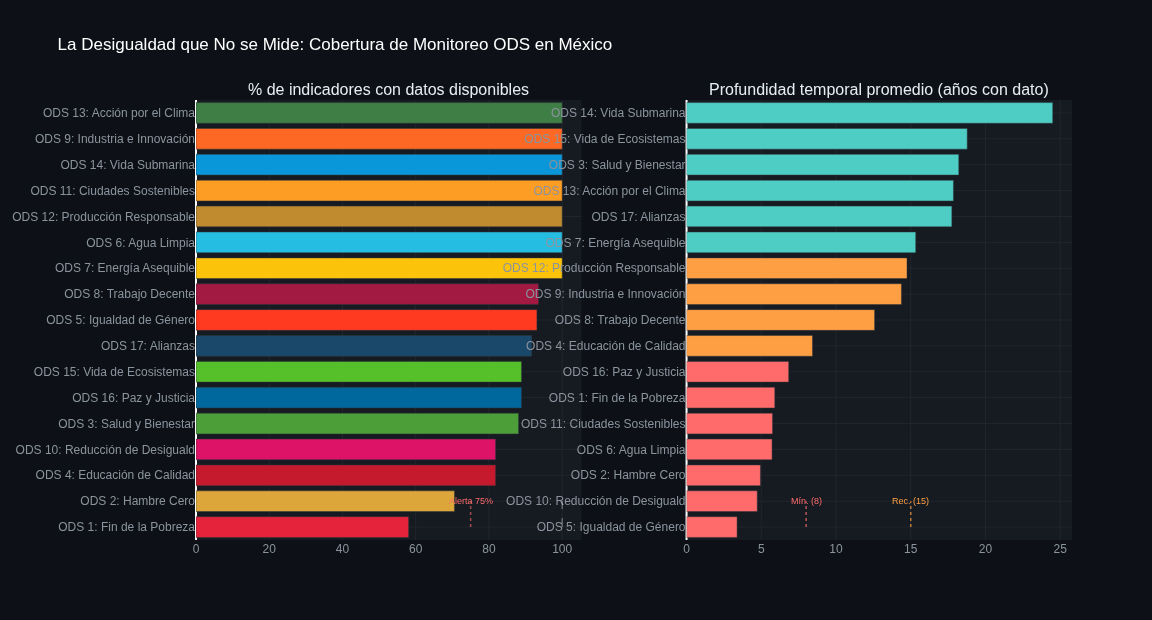

In [5]:
# ── Preparar datos de cobertura ────────────────────────────────────────────────
cob = meta.groupby('ods_number').agg(
    total=('indicator_id', 'count'),
    cargados=('loaded', 'sum'),
    obs_promedio=('n_observations', 'mean')
).reset_index()
cob['pct_cargados'] = cob['cargados'] / cob['total'] * 100
cob['nombre'] = cob['ods_number'].map(ODS_NAMES)
cob['color']  = cob['ods_number'].map(ODS_COLORS)
cob['label']  = cob['ods_number'].apply(lambda n: f'ODS {int(n)}: {ODS_NAMES[int(n)][:22]}')

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        '% de indicadores con datos disponibles',
        'Profundidad temporal promedio (años con dato)',
    ],
    horizontal_spacing=0.12,
)

# ── Panel A: % cargados ────────────────────────────────────────────────────────
sorted_pct = cob.sort_values('pct_cargados')
hover_a = [
    f"<b>{row['label']}</b><br>"
    f"Indicadores con datos: {int(row['cargados'])} / {int(row['total'])}<br>"
    f"Cobertura: {row['pct_cargados']:.1f}%"
    for _, row in sorted_pct.iterrows()
]

fig.add_trace(go.Bar(
    x=sorted_pct['pct_cargados'].tolist(),
    y=sorted_pct['label'].tolist(),
    orientation='h',
    marker_color=sorted_pct['color'].tolist(),
    marker_line_color='#30363D',
    marker_line_width=0.5,
    customdata=hover_a,
    hovertemplate='%{customdata}<extra></extra>',
    name='% con datos',
), row=1, col=1)

# Línea de alerta 75%
# Líneas de referencia en panel A (shapes sobre xaxis)
for xv, lcolor, ldash, lwidth in [(75, '#FF6B6B', 'dot', 1.5), (100, 'white', 'dash', 0.8)]:
    fig.add_shape(type='line',
        x0=xv, x1=xv, y0=0, y1=1, yref='paper',
        xref='x', line=dict(color=lcolor, dash=ldash, width=lwidth), opacity=0.6,
        row=1, col=1)
fig.add_annotation(x=75, y=1.02, xref='x', yref='paper',
    text='Alerta 75%', font=dict(color='#FF6B6B', size=9),
    showarrow=False, row=1, col=1)

# ── Panel B: observaciones promedio ───────────────────────────────────────────
sorted_obs = cob.sort_values('obs_promedio')
urgency_colors = [
    '#FF6B6B' if v < 8 else '#FF9F43' if v < 15 else '#4ECDC4'
    for v in sorted_obs['obs_promedio']
]
hover_b = [
    f"<b>{row['label']}</b><br>"
    f"Promedio de observaciones: {row['obs_promedio']:.1f} años<br>"
    + ('🔴 Crítico (< 8 obs)' if row['obs_promedio'] < 8
       else '🟠 Insuficiente (< 15 obs)' if row['obs_promedio'] < 15
       else '🟢 Aceptable')
    for _, row in sorted_obs.iterrows()
]

fig.add_trace(go.Bar(
    x=sorted_obs['obs_promedio'].tolist(),
    y=sorted_obs['label'].tolist(),
    orientation='h',
    marker_color=urgency_colors,
    marker_line_color='#30363D',
    marker_line_width=0.5,
    customdata=hover_b,
    hovertemplate='%{customdata}<extra></extra>',
    name='Obs. promedio',
), row=1, col=2)

# Líneas de referencia en panel B
for xv, lcolor, lbl in [(8, '#FF6B6B', 'Mín. (8)'), (15, '#FF9F43', 'Rec. (15)')]:
    fig.add_shape(type='line',
        x0=xv, x1=xv, y0=0, y1=1, yref='paper',
        xref='x2', line=dict(color=lcolor, dash='dot', width=1.5), opacity=0.7,
        row=1, col=2)
    fig.add_annotation(x=xv, y=1.02, xref='x2', yref='paper',
        text=lbl, font=dict(color=lcolor, size=9),
        showarrow=False, row=1, col=2)

fig.update_layout(
    title=dict(
        text='La Desigualdad que No se Mide: Cobertura de Monitoreo ODS en México',
        font=dict(size=17, color='white'),
    ),
    **DARK_LAYOUT,
    height=620,
    showlegend=False,
)
fig.update_xaxes(gridcolor='#21262D', tickfont=dict(color='#8B949E'))
fig.update_yaxes(gridcolor='#21262D', tickfont=dict(color='#8B949E'), automargin=True)
fig.show()

---
## ACTO 5 · Los ODS huérfanos
### Bubble chart interactivo: ¿Qué tan bien monitoreamos cada ODS?

Cada burbuja es un ODS. Su tamaño representa cuántos indicadores tiene.  
Su posición muestra cuántos datos reales tiene.  
> Pasa el cursor sobre cualquier burbuja para ver todos los detalles. Usa el zoom con scroll.

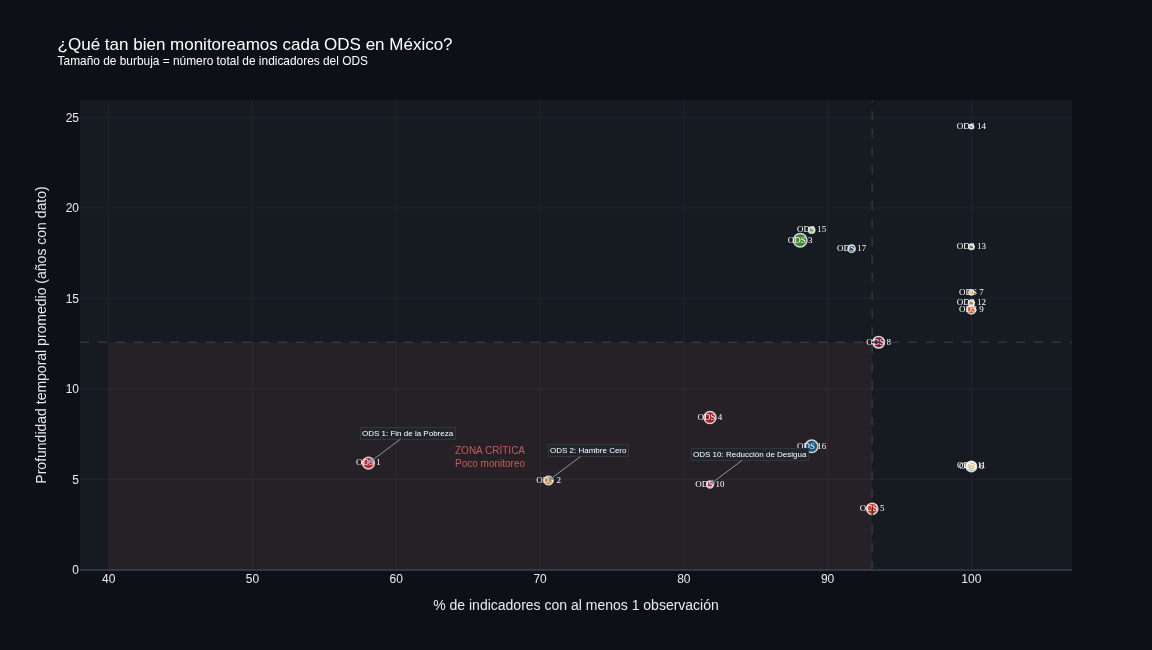

In [6]:
# ── Preparar datos de burbuja ──────────────────────────────────────────────────
obs_reales = largo.groupby('ods_number').agg(
    total_obs=('valor', 'count'),
    n_indicadores_con_dato=('indicator_id', 'nunique')
).reset_index()

bubble = cob.merge(obs_reales, on='ods_number', how='left').fillna(0)
bubble['urgencia'] = (
    (100 - bubble['pct_cargados']) * 0.5 +
    (20 - bubble['obs_promedio'].clip(0, 20)) * 2.5
)
bubble['ods_n'] = bubble['ods_number'].astype(int)

hover_bubble = [
    f"<b>ODS {int(row['ods_number'])}: {ODS_NAMES[int(row['ods_number'])]}</b><br>"
    f"Indicadores totales: {int(row['total'])}<br>"
    f"Con datos: {int(row['cargados'])} ({row['pct_cargados']:.0f}%)<br>"
    f"Obs. promedio: {row['obs_promedio']:.1f} años<br>"
    f"Observaciones reales: {int(row['total_obs']):,}<br>"
    f"Score de urgencia: {row['urgencia']:.1f}"
    for _, row in bubble.iterrows()
]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=bubble['pct_cargados'].tolist(),
    y=bubble['obs_promedio'].tolist(),
    mode='markers+text',
    marker=dict(
        size=[t * 2.2 for t in bubble['total'].tolist()],
        sizemode='area',
        color=bubble['color'].tolist(),
        line=dict(width=1.5, color='white'),
        opacity=0.82,
    ),
    text=[f'ODS {n}' for n in bubble['ods_n'].tolist()],
    textposition='middle center',
    textfont=dict(size=9, color='white', family='Arial Black'),
    customdata=hover_bubble,
    hovertemplate='%{customdata}<extra></extra>',
    name='ODS',
))

# Cuadrantes de urgencia
med_x = bubble['pct_cargados'].median()
med_y = bubble['obs_promedio'].median()

fig.add_vline(x=med_x, line_dash='dash', line_color='#30363D', line_width=1.5)
fig.add_hline(y=med_y, line_dash='dash', line_color='#30363D', line_width=1.5)

fig.add_shape(type='rect',
    x0=40, x1=med_x, y0=0, y1=med_y,
    fillcolor='rgba(255,107,107,0.07)',
    line_width=0,
)
fig.add_annotation(
    x=(40 + med_x) / 2, y=med_y / 2,
    text='ZONA CRÍTICA<br>Poco monitoreo',
    font=dict(color='#FF6B6B', size=10),
    showarrow=False,
    opacity=0.75,
)

# Anotaciones para los ODS más urgentes
top_urgentes = bubble.sort_values('urgencia', ascending=False).head(3)
for _, row in top_urgentes.iterrows():
    fig.add_annotation(
        x=row['pct_cargados'], y=row['obs_promedio'],
        text=f"ODS {int(row['ods_number'])}: {ODS_NAMES[int(row['ods_number'])][:20]}",
        showarrow=True, arrowhead=2, arrowcolor='#8B949E', arrowwidth=1,
        ax=40, ay=-30,
        font=dict(color='white', size=8),
        bgcolor='#21262D', bordercolor='#30363D', borderwidth=1,
    )

fig.update_layout(
    title=dict(
        text='¿Qué tan bien monitoreamos cada ODS en México?<br>'
             '<sup>Tamaño de burbuja = número total de indicadores del ODS</sup>',
        font=dict(size=17, color='white'),
    ),
    xaxis=dict(
        title='% de indicadores con al menos 1 observación',
        gridcolor='#21262D', zerolinecolor='#30363D',
        range=[38, 107],
    ),
    yaxis=dict(
        title='Profundidad temporal promedio (años con dato)',
        gridcolor='#21262D', zerolinecolor='#30363D',
    ),
    **DARK_LAYOUT,
    height=650,
    showlegend=False,
)
fig.show()

---
## ACTO 6 · Dashboard de cierre: Resumen ejecutivo
### Los 5 números que México necesita enfrentar

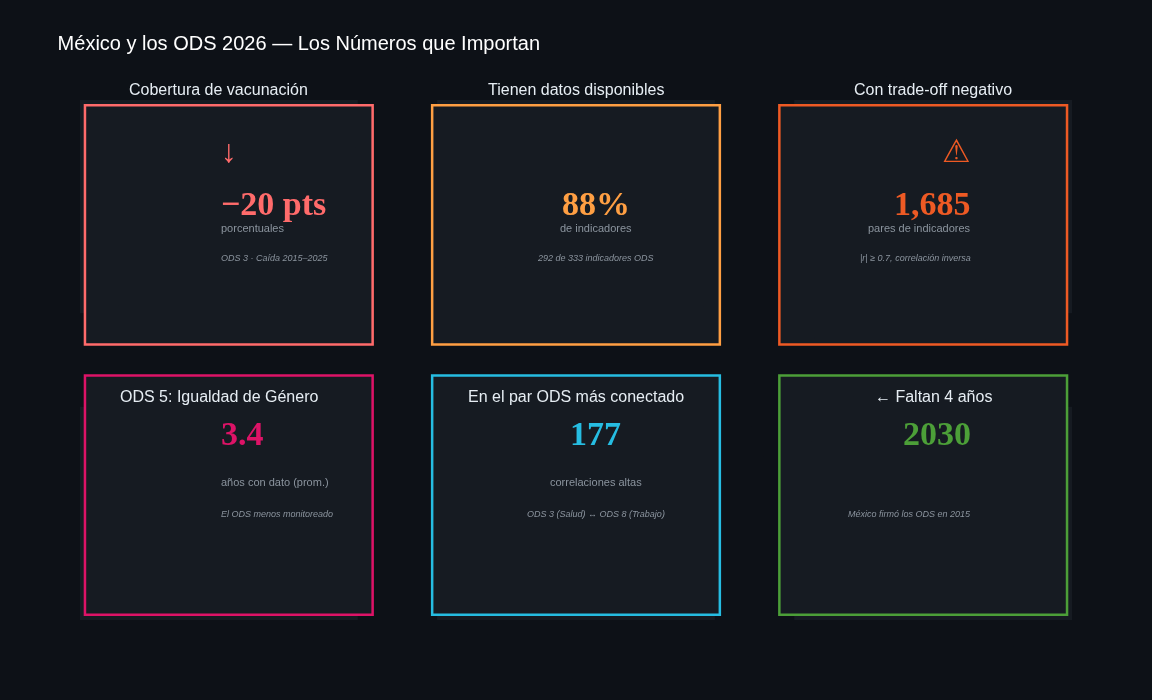

In [7]:
# ── Métricas calculadas ────────────────────────────────────────────────────────
pct_cobertura_global = meta['loaded'].sum() / meta.shape[0] * 100
n_pares_negativos    = corr_altas[corr_altas['correlation'] < -0.7].shape[0]
obs_min_ods          = bubble.sort_values('obs_promedio').iloc[0]
max_correlaciones_par = pares_ods[pares_ods['ODS_A'] != pares_ods['ODS_B']]['n_correlaciones'].max()

cards = [
    dict(value='−20 pts', unit='porcentuales',
         title='Cobertura de vacunación',
         sub='ODS 3 · Caída 2015–2025',
         color='#FF6B6B', arrow='↓'),
    dict(value=f'{pct_cobertura_global:.0f}%', unit='de indicadores',
         title='Tienen datos disponibles',
         sub='292 de 333 indicadores ODS',
         color='#FF9F43', arrow=None),
    dict(value=f'{n_pares_negativos:,}', unit='pares de indicadores',
         title='Con trade-off negativo',
         sub='|r| ≥ 0.7, correlación inversa',
         color='#EE5A24', arrow='⚠'),
    dict(value=f'{obs_min_ods["obs_promedio"]:.1f}', unit='años con dato (prom.)',
         title=f'ODS {int(obs_min_ods.ods_number)}: {ODS_NAMES[int(obs_min_ods.ods_number)][:20]}',
         sub='El ODS menos monitoreado',
         color='#DD1367', arrow=None),
    dict(value=f'{int(max_correlaciones_par)}', unit='correlaciones altas',
         title='En el par ODS más conectado',
         sub='ODS 3 (Salud) ↔ ODS 8 (Trabajo)',
         color='#26BDE2', arrow=None),
    dict(value='2030', unit='',
         title='← Faltan 4 años',
         sub='México firmó los ODS en 2015',
         color='#4C9F38', arrow=None),
]

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[c['title'] for c in cards],
    vertical_spacing=0.18,
    horizontal_spacing=0.08,
)

positions = [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3)]

for (r, c), card in zip(positions, cards):
    # Traza vacía para ocupar el subplot
    fig.add_trace(go.Scatter(
        x=[0], y=[0], mode='markers',
        marker=dict(size=1, color='rgba(0,0,0,0)'),
        showlegend=False, hoverinfo='none',
    ), row=r, col=c)

    # Calcular posición del subplot en coordenadas de papel
    col_idx = c - 1
    row_idx = r - 1
    x_center = (col_idx * 0.38) + 0.14
    y_center = 1.0 - (row_idx * 0.52) - 0.16

    if card['arrow']:
        fig.add_annotation(
            xref='paper', yref='paper',
            x=x_center, y=y_center + 0.10,
            text=card['arrow'],
            font=dict(size=32, color=card['color'], family='Arial Black'),
            showarrow=False,
        )

    fig.add_annotation(
        xref='paper', yref='paper',
        x=x_center, y=y_center,
        text=f"<b>{card['value']}</b>",
        font=dict(size=34, color=card['color'], family='Arial Black'),
        showarrow=False,
    )
    fig.add_annotation(
        xref='paper', yref='paper',
        x=x_center, y=y_center - 0.07,
        text=card['unit'],
        font=dict(size=11, color='#8B949E'),
        showarrow=False,
    )
    fig.add_annotation(
        xref='paper', yref='paper',
        x=x_center, y=y_center - 0.13,
        text=f"<i>{card['sub']}</i>",
        font=dict(size=9, color='#8B949E'),
        showarrow=False,
    )

# Bordes de color por tarjeta
shapes_cards = []
domain_x = [(0.0, 0.30), (0.35, 0.65), (0.70, 1.0)]
domain_y = [(0.52, 1.0), (0.0, 0.48)]
for idx, card in enumerate(cards):
    r_i, c_i = divmod(idx, 3)
    x0, x1 = domain_x[c_i]
    y0, y1 = domain_y[r_i]
    shapes_cards.append(dict(
        type='rect', xref='paper', yref='paper',
        x0=x0 + 0.005, x1=x1 - 0.005,
        y0=y0 + 0.01,  y1=y1 - 0.01,
        line=dict(color=card['color'], width=2.5),
        fillcolor='#161B22',
    ))

fig.update_layout(
    title=dict(
        text='México y los ODS 2026 — Los Números que Importan',
        font=dict(size=20, color='white'),
    ),
    **DARK_LAYOUT,
    height=700,
    shapes=shapes_cards,
    showlegend=False,
)
fig.update_xaxes(showgrid=False, showticklabels=False, zeroline=False)
fig.update_yaxes(showgrid=False, showticklabels=False, zeroline=False)
fig.show()

---

## Cierre narrativo

> **"No es falta de datos. Es una decisión de qué queremos ver."**
>
> México tiene 333 indicadores ODS. Solo 292 tienen datos.  
> Los que menos datos tienen son los que miden desigualdad y hambre.  
> Los que más datos tienen — salud, trabajo — muestran tendencias preocupantes.  
>
> **2030 no es una fecha lejana. Es el próximo sexenio.**

### Gráficas generadas (interactivas)
| Acto | Visualización |
|------|---------------|
| 1 | Red de interdependencias ODS (grafo interactivo) |
| 2 | Series de tiempo ODS 3 — Salud en deterioro |
| 3 | Heatmap de correlaciones + Pares más interconectados |
| 4 | Cobertura de datos por ODS (doble panel) |
| 5 | Bubble chart — ODS huérfanos |
| 6 | Dashboard de 5 métricas de impacto |